In [2]:
!mamba install pandas numpy matplotlib seaborn


mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 1.232 seconds
  Name           Version  Build                Channel
--------------------------------------------------------------------
+ pandas         3.0.4    np23py313h1e705a5_0  emscripten-forge-4x
+ patsy          1.0.2    py313h1804a44_3      emscripten-forge-4x
+ python-tzdata  2026.3   pyhd8ed1ab_0         conda-forge
+ seaborn        0.13.2   hd8ed1ab_3           conda-forge
+ seaborn-base   0.13.2   pyhd8ed1ab_3         conda-forge
+ statsmodels    0.14.6   np23py313hd8db738_2  emscripten-forge-4x
- pip            26.1.2   pyh145f28c_0         conda-forge


In [5]:
# =====================================================================
# Project Deliverable 1: Data Collection, Cleaning, and Exploration
# =====================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Configure visual aesthetics for exploratory data analysis
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [7]:
# ---------------------------------------------------------------------
# Task 1: Data Loading and Structural Inspection
# ---------------------------------------------------------------------
# Load the dataset
df = pd.read_csv('healthcare_dataset.csv')

# Inspect structure and data types
print("Dataset Shape:", df.shape)
print("\n--- Data Types and Non-Null Counts ---")
df.info()

Dataset Shape: (55500, 15)

--- Data Types and Non-Null Counts ---
<class 'pandas.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  str    
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  str    
 3   Blood Type          55500 non-null  str    
 4   Medical Condition   55500 non-null  str    
 5   Date of Admission   55500 non-null  str    
 6   Doctor              55500 non-null  str    
 7   Hospital            55500 non-null  str    
 8   Insurance Provider  55500 non-null  str    
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  str    
 12  Discharge Date      55500 non-null  str    
 13  Medication          55500 non-null  str    
 14  Test Results        55500 non-null  str    
dt

In [8]:
# Display initial rows to observe raw data formatting
display(df.head())

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [9]:
# ---------------------------------------------------------------------
# Task 2: Data Cleaning - Deduplication & Standardization
# ---------------------------------------------------------------------
# 1. Remove exact duplicate records
initial_rows = len(df)
df = df.drop_duplicates()
print(f"\nRemoved {initial_rows - len(df)} duplicate patient records.")


Removed 534 duplicate patient records.


In [10]:
# 2. Standardize inconsistent text formatting in the 'Name' column
df['Name'] = df['Name'].str.title()

In [11]:
# 3. Handle Missing Values
# While this specific dataset export may be structurally complete, robust pipelines must check
missing_summary = df.isnull().sum()
print("\nMissing Values Post-Deduplication:\n", missing_summary[missing_summary > 0] if missing_summary.any() else "No missing values detected.")


Missing Values Post-Deduplication:
 No missing values detected.


In [12]:
# ---------------------------------------------------------------------
# Task 3: Addressing Noisy Data & Feature Engineering
# ---------------------------------------------------------------------
# Fix logically impossible negative values in 'Billing Amount'
invalid_billing_count = (df['Billing Amount'] < 0).sum()
print(f"\nIdentified {invalid_billing_count} records with negative (noisy) billing amounts.")


Identified 106 records with negative (noisy) billing amounts.


In [13]:
# Impute negative billing amounts with the median of the valid positive bills
valid_median_bill = df[df['Billing Amount'] >= 0]['Billing Amount'].median()
df.loc[df['Billing Amount'] < 0, 'Billing Amount'] = valid_median_bill

# Feature Engineering: Convert string dates to datetime objects to calculate Length of Stay
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])

# Create new feature: Length of Stay (in days)
df['Length_of_Stay'] = (df['Discharge Date'] - df['Date of Admission']).dt.days

print("\nData cleaning protocols and temporal feature engineering executed successfully.")


Data cleaning protocols and temporal feature engineering executed successfully.


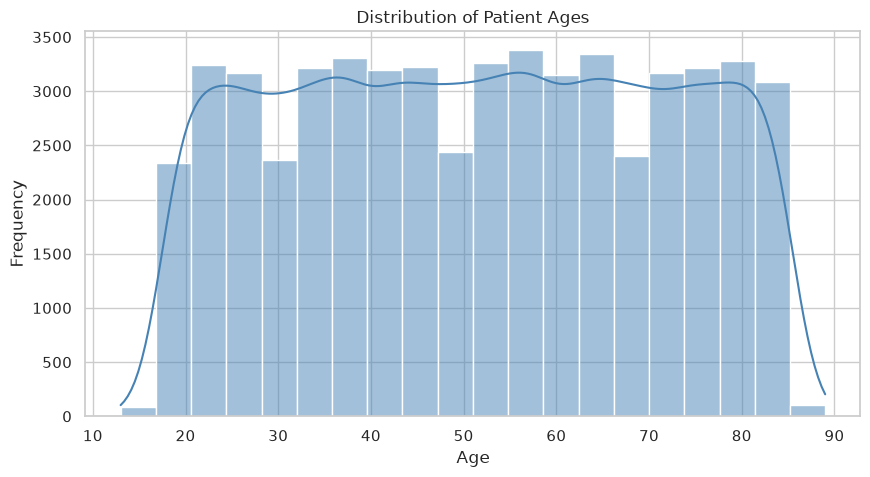

In [14]:
# ---------------------------------------------------------------------
# Task 4: Exploratory Data Analysis - Distributions & Relationships
# ---------------------------------------------------------------------

# Plot 1: Distribution of Patient Ages
plt.figure(figsize=(10, 5))
sns.histplot(df['Age'], bins=20, kde=True, color='steelblue')
plt.title('Distribution of Patient Ages')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()